# 📊 Analyse du Churn Client — Telco 360
## Objectif
Identifier les profils de clients les plus susceptibles de résilier 
leur abonnement afin de proposer des actions de rétention ciblées.

## Stack technique
- Python (Pandas, Matplotlib, Seaborn, Scikit-learn)
- Dataiku DSS
- PostgreSQL
- Tableau

**Auteur :** Mérick | Data Analyst Junior

In [3]:
import pandas as pd
import numpy as np

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

In [9]:
print ("✅ Bibliothèques importées avec succès !")

✅ Bibliothèques importées avec succès !


In [11]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"✅ Dataset chargé : {df.shape[0]} clients, {df.shape[1]} variables")
df.head()

✅ Dataset chargé : 7043 clients, 21 variables


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Éxploration initiale du dataset

In [15]:
print("=" * 50)
print("DIMENSIONS DU DATASET")
print("=" * 50)
print(f"Nombre de clients : {df.shape[0]}")
print(f"Nombre de variables : {df.shape[1]}")

print("\n" + "=" * 50)
print("TYPES DE VARIABLES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("VALEURS MANQUANTES")
print("=" * 50)
print(df.isnull().sum())

DIMENSIONS DU DATASET
Nombre de clients : 7043
Nombre de variables : 21

TYPES DE VARIABLES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

VALEURS MANQUANTES
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0


## Nettoyage des données

In [18]:
# ── Correction de TotalCharges ────────────────────────────
# On remplace les espaces vides par NaN, puis on convertit en float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Vérification : combien de NaN sont apparus ?
print(f"Valeurs manquantes dans TotalCharges : {df['TotalCharges'].isnull().sum()}")

# On supprime ces lignes (ce sont des clients avec tenure = 0, donc tout nouveaux)
df = df.dropna(subset=['TotalCharges'])
print(f"Dataset après nettoyage : {df.shape[0]} clients")

# ── Correction de SeniorCitizen ───────────────────────────
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# ── Suppression de customerID ─────────────────────────────
# C'est juste un identifiant, inutile pour l'analyse
df = df.drop(columns=['customerID'])

print("\n✅ Nettoyage terminé !")
print(df.dtypes)

Valeurs manquantes dans TotalCharges : 11
Dataset après nettoyage : 7032 clients

✅ Nettoyage terminé !
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


## Statistiques descriptives

In [21]:
print("=" * 50)
print("VARIABLES NUMÉRIQUES")
print("=" * 50)
df.describe()

VARIABLES NUMÉRIQUES


,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [23]:
print("=" * 50)
print("VARIABLES CATÉGORIELLES")
print("=" * 50)
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col} ({df[col].nunique()} valeurs uniques) :")
    print(df[col].value_counts())
    print("-" * 30)

VARIABLES CATÉGORIELLES

gender (2 valeurs uniques) :
gender
Male      3549
Female    3483
Name: count, dtype: int64
------------------------------

SeniorCitizen (2 valeurs uniques) :
SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64
------------------------------

Partner (2 valeurs uniques) :
Partner
No     3639
Yes    3393
Name: count, dtype: int64
------------------------------

Dependents (2 valeurs uniques) :
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
------------------------------

PhoneService (2 valeurs uniques) :
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
------------------------------

MultipleLines (3 valeurs uniques) :
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
------------------------------

InternetService (3 valeurs uniques) :
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
--------------------

## Analyse visuelle

### Distribution du churn (variable cible)

/var/folders/sc/9c5fk7450t9dh1mx418fzy300000gn/T/ipykernel_13839/332365700.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])


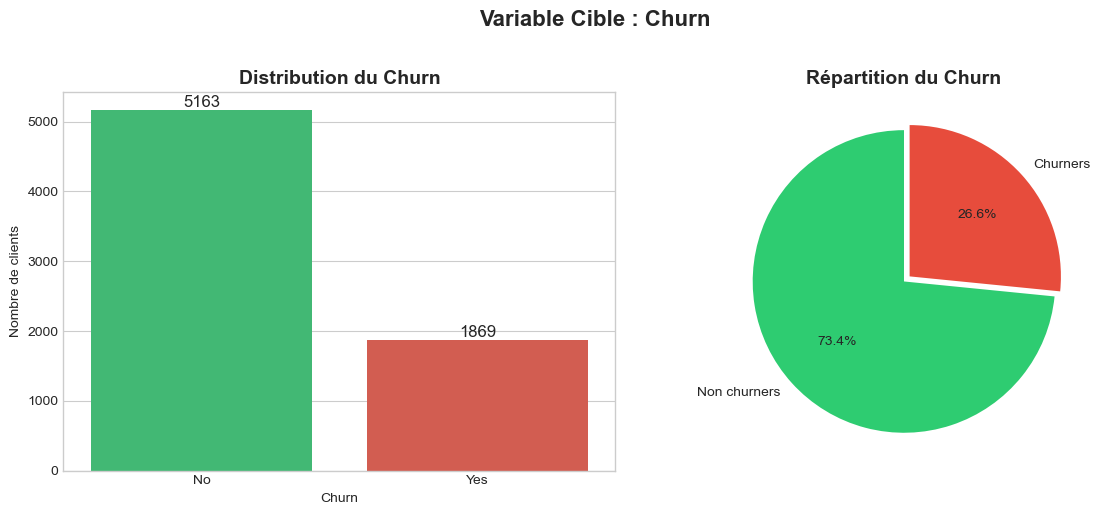

✅ Graphique sauvegardé !


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Graphique 1 : Countplot ───────────────────────────────
sns.countplot(data=df, x='Churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution du Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Nombre de clients')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# ── Graphique 2 : Pie chart ───────────────────────────────
churn_counts = df['Churn'].value_counts()
axes[1].pie(churn_counts, 
            labels=['Non churners', 'Churners'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Répartition du Churn', fontsize=14, fontweight='bold')

plt.suptitle('Variable Cible : Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_distribution_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

### Churn par variables clés

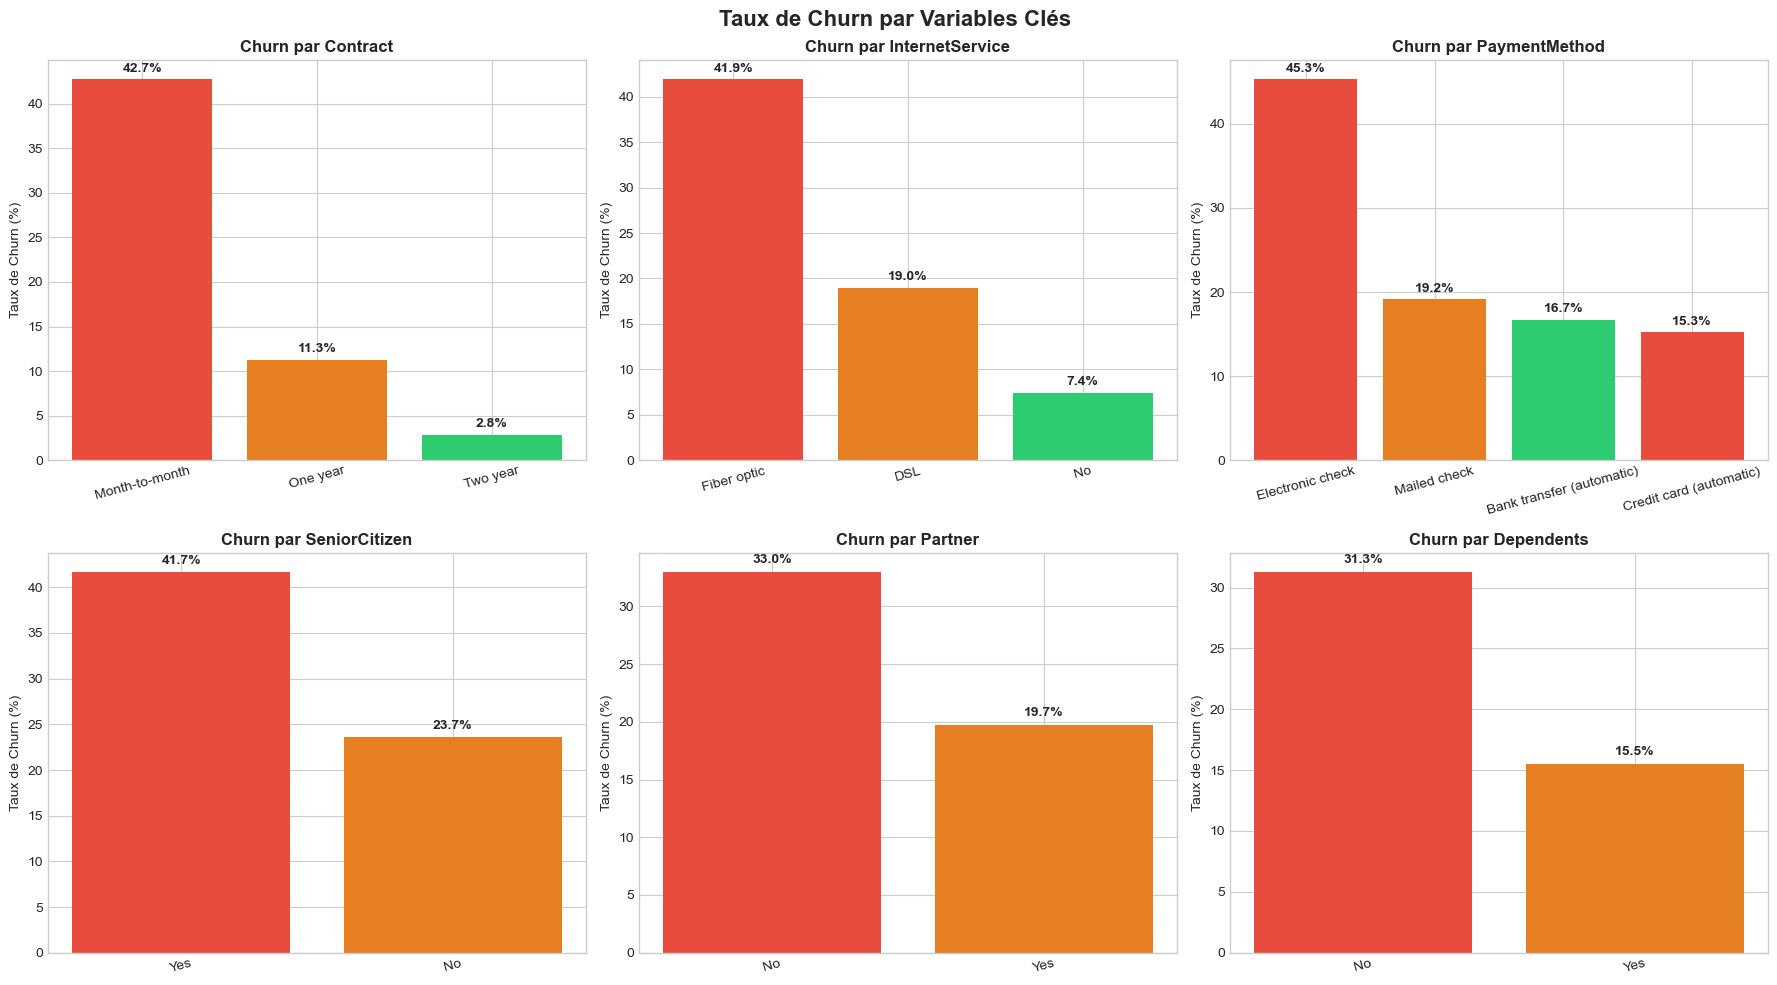

✅ Graphique sauvegardé !


In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

variables = ['Contract', 'InternetService', 'PaymentMethod', 
             'SeniorCitizen', 'Partner', 'Dependents']

for ax, var in zip(axes.flatten(), variables):
    churn_rate = df.groupby(var)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [var, 'Taux de Churn (%)']
    churn_rate = churn_rate.sort_values('Taux de Churn (%)', ascending=False)
    
    bars = ax.bar(churn_rate[var], churn_rate['Taux de Churn (%)'],
                  color=['#e74c3c', '#e67e22', '#2ecc71'][:len(churn_rate)])
    ax.set_title(f'Churn par {var}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Taux de Churn (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    
    for bar, val in zip(bars, churn_rate['Taux de Churn (%)']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Taux de Churn par Variables Clés', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_churn_par_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

### Distribution des variables numériques selon le churn

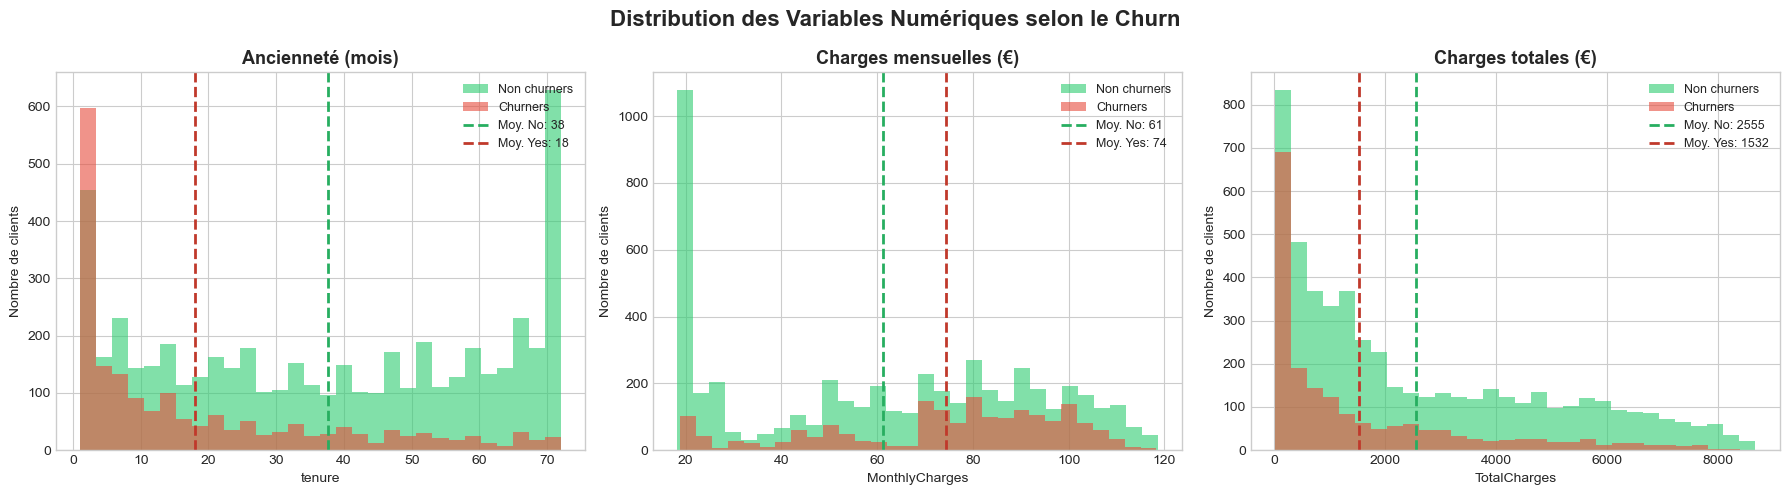

✅ Graphique sauvegardé !


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables_num = ['tenure', 'MonthlyCharges', 'TotalCharges']
titres = ['Ancienneté (mois)', 'Charges mensuelles (€)', 'Charges totales (€)']

for ax, var, titre in zip(axes, variables_num, titres):
    df[df['Churn'] == 'No'][var].hist(ax=ax, alpha=0.6, color='#2ecc71', 
                                       bins=30, label='Non churners')
    df[df['Churn'] == 'Yes'][var].hist(ax=ax, alpha=0.6, color='#e74c3c', 
                                        bins=30, label='Churners')
    ax.set_title(titre, fontsize=13, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Nombre de clients')
    ax.legend()

    # Lignes de moyenne
    mean_no = df[df['Churn'] == 'No'][var].mean()
    mean_yes = df[df['Churn'] == 'Yes'][var].mean()
    ax.axvline(mean_no, color='#27ae60', linestyle='--', linewidth=2,
               label=f'Moy. No: {mean_no:.0f}')
    ax.axvline(mean_yes, color='#c0392b', linestyle='--', linewidth=2,
               label=f'Moy. Yes: {mean_yes:.0f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribution des Variables Numériques selon le Churn', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('03_distributions_numeriques.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

### Matrice de corrélation

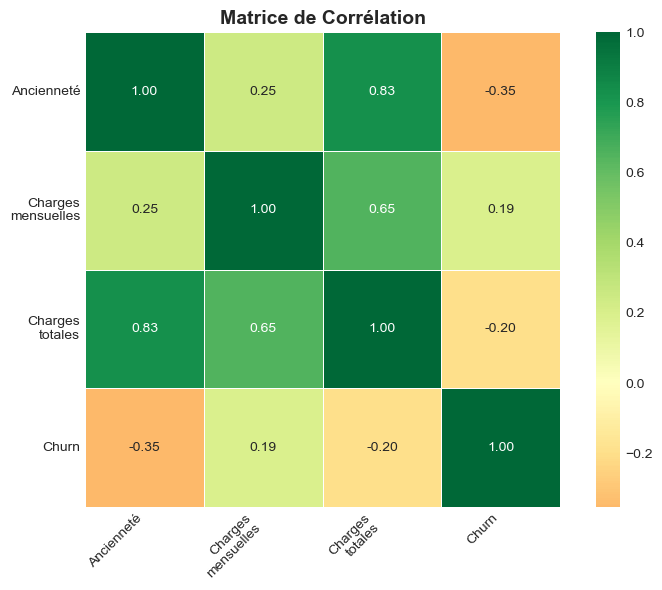

✅ Graphique sauvegardé !


In [42]:
fig, ax = plt.subplots(figsize=(8, 6))

# On crée une variable numérique pour Churn (Yes=1, No=0)
df_corr = df.copy()
df_corr['Churn_num'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# On sélectionne uniquement les variables numériques
corr_matrix = df_corr[['tenure', 'MonthlyCharges', 
                         'TotalCharges', 'Churn_num']].corr()

# Heatmap
sns.heatmap(corr_matrix, 
            annot=True,          # Affiche les valeurs
            fmt='.2f',           # 2 décimales
            cmap='RdYlGn',       # Rouge = corrélation négative, Vert = positive
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Matrice de Corrélation', fontsize=14, fontweight='bold')

# Renommer les axes pour plus de lisibilité
labels = ['Ancienneté', 'Charges\nmensuelles', 'Charges\ntotales', 'Churn']
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels, rotation=0)

plt.tight_layout()
plt.savefig('04_matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

### Profil type du churner vs. non-churner

/var/folders/sc/9c5fk7450t9dh1mx418fzy300000gn/T/ipykernel_13839/1675635889.py:92: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) Arial.
  plt.savefig('05_profil_churner.png', dpi=150, bbox_inches='tight')
/var/folders/sc/9c5fk7450t9dh1mx418fzy300000gn/T/ipykernel_13839/1675635889.py:92: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig('05_profil_churner.png', dpi=150, bbox_inches='tight')
/var/folders/sc/9c5fk7450t9dh1mx418fzy300000gn/T/ipykernel_13839/1675635889.py:92: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.savefig('05_profil_churner.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missi

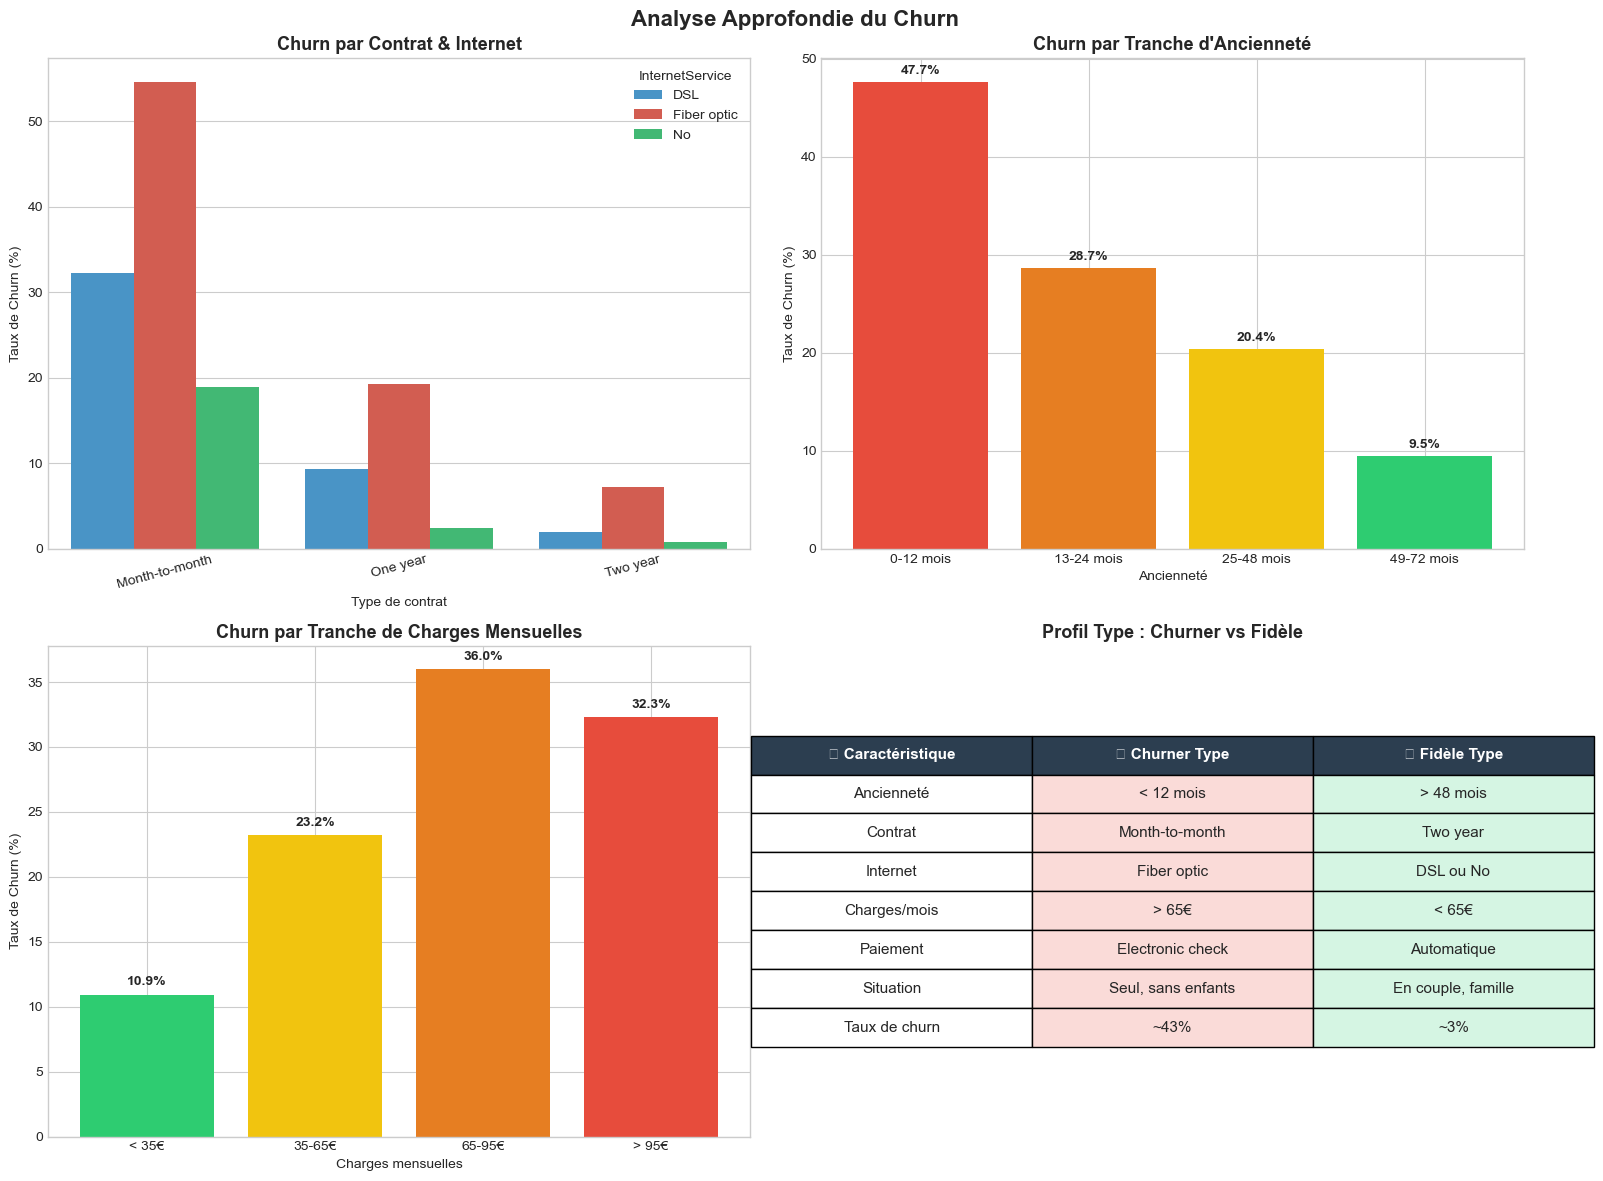

✅ Graphique sauvegardé !


In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Graphique 1 : Churn par Contract ET InternetService ───
contract_internet = df.groupby(['Contract', 'InternetService'])['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
contract_internet.columns = ['Contract', 'InternetService', 'Taux de Churn (%)']

sns.barplot(data=contract_internet, x='Contract', y='Taux de Churn (%)',
            hue='InternetService', ax=axes[0,0],
            palette=['#3498db', '#e74c3c', '#2ecc71'])
axes[0,0].set_title('Churn par Contrat & Internet', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Type de contrat')
axes[0,0].tick_params(axis='x', rotation=15)

# ── Graphique 2 : Churn par tranche d'ancienneté ──────────
df['tenure_segment'] = pd.cut(df['tenure'], 
                               bins=[0, 12, 24, 48, 72],
                               labels=['0-12 mois', '13-24 mois', 
                                       '25-48 mois', '49-72 mois'])

tenure_churn = df.groupby('tenure_segment', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
tenure_churn.columns = ['Segment', 'Taux de Churn (%)']

bars = axes[0,1].bar(tenure_churn['Segment'], tenure_churn['Taux de Churn (%)'],
                      color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'])
axes[0,1].set_title('Churn par Tranche d\'Ancienneté', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Ancienneté')
axes[0,1].set_ylabel('Taux de Churn (%)')
for bar, val in zip(bars, tenure_churn['Taux de Churn (%)']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# ── Graphique 3 : Churn par MonthlyCharges (tranches) ─────
df['charges_segment'] = pd.cut(df['MonthlyCharges'],
                                bins=[0, 35, 65, 95, 120],
                                labels=['< 35€', '35-65€', '65-95€', '> 95€'])

charges_churn = df.groupby('charges_segment', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
charges_churn.columns = ['Segment', 'Taux de Churn (%)']

bars2 = axes[1,0].bar(charges_churn['Segment'], charges_churn['Taux de Churn (%)'],
                       color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
axes[1,0].set_title('Churn par Tranche de Charges Mensuelles', 
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Charges mensuelles')
axes[1,0].set_ylabel('Taux de Churn (%)')
for bar, val in zip(bars2, charges_churn['Taux de Churn (%)']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# ── Graphique 4 : Tableau récap profil churner ────────────
axes[1,1].axis('off')
profil_data = [
    ['📋 Caractéristique', '🔴 Churner Type', '🟢 Fidèle Type'],
    ['Ancienneté', '< 12 mois', '> 48 mois'],
    ['Contrat', 'Month-to-month', 'Two year'],
    ['Internet', 'Fiber optic', 'DSL ou No'],
    ['Charges/mois', '> 65€', '< 65€'],
    ['Paiement', 'Electronic check', 'Automatique'],
    ['Situation', 'Seul, sans enfants', 'En couple, famille'],
    ['Taux de churn', '~43%', '~3%'],
]

table = axes[1,1].table(cellText=profil_data[1:],
                         colLabels=profil_data[0],
                         loc='center',
                         cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

# Couleurs du tableau
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 1:
        cell.set_facecolor('#fadbd8')
    elif col == 2:
        cell.set_facecolor('#d5f5e3')

axes[1,1].set_title('Profil Type : Churner vs Fidèle', 
                     fontsize=13, fontweight='bold')

plt.suptitle('Analyse Approfondie du Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('05_profil_churner.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")